# Cooling a cavity with descending JC swaps, and counting photons for free

One **round** of the protocol:

1. Turn on the resonant Jaynes-Cummings interaction $H = g(\sigma_+ a + \sigma_- a^\dagger)$
   for a time tuned to a *full* swap on one Fock level.
2. Measure the qubit.
3. If it came out in $|e\rangle$, apply a $\pi$ pulse to put it back in $|g\rangle$.

Do the swaps in **descending** order: full swap on level $K$, then $K-1$, then $K-2$, ..., then $1$.
A cavity state with support up to $N$ is driven to exactly $|0\rangle$ in exactly $N$ rounds --
you cannot do better, because each round removes at most one photon.

That same fact makes this a photon counter. Each $|e\rangle$ outcome removes *exactly* one photon,
and the sweep always finishes in $|0\rangle$, so the total number of $|e\rangle$ outcomes in one
run **is** the photon number. The last cell histograms that count over many runs and overlays the
ideal $p_n = |\langle n|\psi\rangle|^2$ of the initial state. They should agree to within
Monte Carlo sampling error.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import basis, destroy, qeye, tensor, coherent, expect

## Operators

One note on conventions: QuTiP's built-in `sigmap()` treats `basis(2, 0)` as the *excited*
state, which is easy to trip over. We define the raising and lowering operators by hand
instead, so there is no ambiguity about which state is which.

Throughout, tensor products are ordered `tensor(qubit_operator, cavity_operator)`.

In [2]:
N_CAV = 16        # cavity Fock space: |0>, |1>, ..., |15>
K = N_CAV - 1     # rounds per run = highest level we need to clear
g = 1.0           # coupling strength; all times below are in units of 1/g

# ---- qubit ----
ket_g = basis(2, 0)                  # ground state
ket_e = basis(2, 1)                  # excited state
sigma_plus  = ket_e * ket_g.dag()    # |e><g|, raises the qubit
sigma_minus = ket_g * ket_e.dag()    # |g><e|, lowers the qubit

# ---- cavity ----
a = destroy(N_CAV)

# ---- identities, for building tensor products ----
I_q = qeye(2)
I_c = qeye(N_CAV)

# Resonant Jaynes-Cummings Hamiltonian in the rotating frame.
H = g * (tensor(sigma_plus, a) + tensor(sigma_minus, a.dag()))

# Projectors for the qubit measurement...
P_g = tensor(ket_g * ket_g.dag(), I_c)
P_e = tensor(ket_e * ket_e.dag(), I_c)

# ...and the pi pulse that resets |e> -> |g>. It acts on the qubit only.
X_pi = tensor(sigma_plus + sigma_minus, I_c)

## Swap times

Inside the two-state subspace $\{|g,n\rangle,\ |e,n-1\rangle\}$ the Hamiltonian is just
$g\sqrt{n}\,\sigma_x$, so the pair oscillates at rate $g\sqrt{n}$. A full swap on level $f$
(sending $|g,f\rangle \to |e,f-1\rangle$ with probability 1) therefore needs

$$ g\,t_f = \frac{\pi}{2\sqrt{f}} $$

High levels swap fast and low levels swap slowly, so a descending schedule starts with short
pulses and ends with the longest one, $g t_1 = \pi/2$.

We precompute the propagator $U_f = e^{-i H t_f}$ for each level once, since we will reuse
them thousands of times.

In [3]:
swap_time = {}
U = {}

for f in range(1, K + 1):
    swap_time[f] = np.pi / (2 * g * np.sqrt(f))
    U[f] = (-1j * H * swap_time[f]).expm()

print("first pulse  (f = %2d):  g*t = %.4f" % (K, swap_time[K]))
print("second pulse (f = %2d):  g*t = %.4f" % (K - 1, swap_time[K - 1]))
print("last pulse   (f = %2d):  g*t = %.4f" % (1, swap_time[1]))
print()
print("total interaction time:  g*T = %.4f" % sum(swap_time.values()))

first pulse  (f = 15):  g*t = 0.4056
second pulse (f = 14):  g*t = 0.4198
last pulse   (f =  1):  g*t = 1.5708

total interaction time:  g*T = 10.0751


## One run

Everything stays a pure state, so a single run is simple: apply the propagator, read off the
probability of finding the qubit in $|e\rangle$, flip a weighted coin, project onto whichever
outcome you got, reset the qubit if needed, repeat.

In [4]:
def one_run(cavity_state, rng):
    '''Run the full descending sweep once.

    Returns (number of times the qubit was measured in |e>, final joint state).
    '''
    psi = tensor(ket_g, cavity_state)   # the qubit always starts in |g>
    clicks = 0

    for f in range(K, 0, -1):           # descending order: K, K-1, ..., 1
        psi = U[f] * psi                # 1. swap tuned to a full transfer on level f

        prob_e = expect(P_e, psi).real  # 2. measure the qubit

        if rng.random() < prob_e:
            psi = (P_e * psi).unit()    #    outcome was |e>: project and renormalise
            psi = X_pi * psi            # 3. pi pulse brings the qubit back to |g>
            clicks += 1                 #    one photon just left the cavity
        else:
            psi = (P_g * psi).unit()    #    outcome was |g>: project, qubit already in |g>

    return clicks, psi

## Two quick sanity checks before the main run

The first confirms the cooling claim: the cavity really ends in vacuum, not merely close to it.

The second confirms the counting claim in its sharpest form. A Fock state $|n\rangle$ gives
**exactly** $n$ clicks in every single run -- the timing of the clicks is random, but the total
is not. That is the whole reason the click count is a faithful photon-number readout.

In [5]:
rng = np.random.default_rng(0)
n_op = tensor(I_q, a.dag() * a)

clicks, psi_final = one_run(coherent(N_CAV, 2.0), rng)
print("one run on a coherent state:  clicks = %d,  final cavity <n> = %.2e"
      % (clicks, expect(n_op, psi_final).real))
print()

for n_test in [3, 7, 12]:
    observed = set()
    for _ in range(50):
        clicks, _ = one_run(basis(N_CAV, n_test), rng)
        observed.add(clicks)
    print("Fock |%2d>  ->  click counts seen over 50 runs: %s" % (n_test, sorted(observed)))

one run on a coherent state:  clicks = 5,  final cavity <n> = 1.27e-34

Fock | 3>  ->  click counts seen over 50 runs: [3]
Fock | 7>  ->  click counts seen over 50 runs: [7]
Fock |12>  ->  click counts seen over 50 runs: [12]


## Main run: repeat the protocol many times on the same initial state

We use a coherent state, whose photon-number distribution is Poissonian with mean
$\bar n = |\alpha|^2$. Each run is independent and starts from a freshly prepared copy of the
same `cavity_0`.

In [6]:
alpha = 2.0
cavity_0 = coherent(N_CAV, alpha)

# The ideal photon-number distribution of the initial state. For a pure state this is just
# |<n|psi>|^2, i.e. the squared magnitudes of the state vector's entries.
p_ideal = np.abs(cavity_0.full().flatten()) ** 2

M = 4000                          # number of runs
click_counts = np.zeros(N_CAV)    # click_counts[c] = how many runs gave c clicks

for shot in range(M):
    clicks, psi_final = one_run(cavity_0, rng)
    click_counts[clicks] += 1

p_measured = click_counts / M

# Binomial (multinomial) sampling error on each bin, from M independent runs.
p_error = np.sqrt(p_measured * (1 - p_measured) / M)

n = np.arange(N_CAV)
print("mean click count       : %.4f" % (p_measured @ n))
print("ideal <n> of the state : %.4f" % (p_ideal @ n))
print()
print("largest bin residual   : %.5f" % np.abs(p_measured - p_ideal).max())
print("typical sampling error : %.5f" % p_error.max())
print("total variation dist.  : %.5f" % (0.5 * np.abs(p_measured - p_ideal).sum()))

mean click count       : 3.9770
ideal <n> of the state : 4.0000

largest bin residual   : 0.00628
typical sampling error : 0.00631
total variation dist.  : 0.01467


## The histogram, against the ideal photon-number distribution

Top panel: the measured click-count histogram side by side with the ideal $p_n$.
Bottom panel: the residual, with the $\pm 1\sigma$ Monte Carlo band. Every residual should sit
inside the band -- the two distributions are not merely similar, they are the same distribution,
and the only scatter is from having taken finitely many runs.

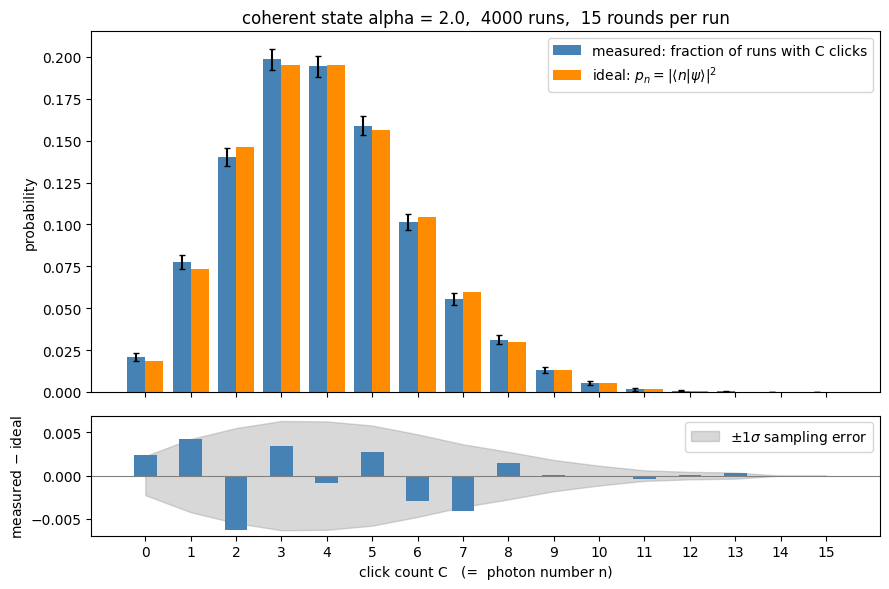

In [7]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 6), sharex=True,
                               gridspec_kw={"height_ratios": [3, 1]})

# ---- top: the two histograms side by side ----
ax1.bar(n - 0.2, p_measured, width=0.4, color="steelblue",
        yerr=p_error, capsize=2, label="measured: fraction of runs with C clicks")
ax1.bar(n + 0.2, p_ideal, width=0.4, color="darkorange",
        label=r"ideal: $p_n = |\langle n | \psi \rangle |^2$")
ax1.set_ylabel("probability")
ax1.set_title("coherent state alpha = %.1f,  %d runs,  %d rounds per run"
              % (alpha, M, K))
ax1.legend()

# ---- bottom: residual, with the sampling-error band ----
ax2.fill_between(n, -p_error, p_error, color="gray", alpha=0.3,
                 label=r"$\pm 1\sigma$ sampling error")
ax2.axhline(0.0, color="gray", linewidth=0.8)
ax2.bar(n, p_measured - p_ideal, width=0.5, color="steelblue")
ax2.set_xlabel("click count C   (=  photon number n)")
ax2.set_ylabel("measured $-$ ideal")
ax2.set_xticks(n)
ax2.legend()

fig.tight_layout()
plt.show()

## Things to try

- Set `N_CAV` larger and `alpha` larger. The number of rounds you need scales as
  $\bar n + \mathcal{O}(\sqrt{\bar n})$, while the total interaction time only grows like
  $g T \approx \pi\sqrt{K}$.
- Raise `M`. The residual band shrinks as $1/\sqrt{M}$ while the residuals shrink with it,
  which is the real content of the comparison.
- Replace `coherent(N_CAV, alpha)` with a thermal state. That is a mixed state, so you would
  sample a Fock state from its diagonal first and then call `one_run` on it -- legitimate here
  because the click statistics depend only on the diagonal $p_n$, never on coherences.
- Multiply `swap_time[f]` by `1.05` to see what a 5% systematic timing error costs. With `K`
  comfortably above the state's support the damage is small, because a mistimed swap just leaves
  population one level behind the descending front and the front sweeps it up later.